# Chapter 2: Tackle a regression task on Vehicle Pricing

## Frame the Problem

We need to predict the prices of vehicles based on their characterisitcs.

I will use regression models and measure the performances according to RSME to reach at max 10% error.

## Get the Data

In [188]:
from pathlib import Path
import pandas as pd

def laod_data_csv(path:str) -> pd.DataFrame:
    """
    Load data from a CSV file into a pandas DataFrame.

    Parameters:
    path (str): The file path to the CSV file.

    Returns:
    pd.DataFrame: A DataFrame containing the loaded data.
    """
    path = Path(path)
    return pd.read_csv(path)
    

In [189]:
vehicle = laod_data_csv("datasets/vehicle.csv")

In [190]:
vehicle.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [191]:
vehicle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [192]:
vehicle['year'].value_counts()

year
2017    466
2015    421
2012    415
2013    386
2014    367
2018    366
2016    357
2011    271
2010    234
2019    195
2009    193
2008    145
2007    134
2006    110
2005     85
2020     48
2004     42
2003     23
2002     21
2001     20
1998     12
2000     12
1999     10
1997      3
1996      2
1995      1
1992      1
Name: count, dtype: int64

In [193]:
vehicle.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


We got 8 features with km_driven and selling_price as numerical and the others are categorical or text and we got 27 differents years, maybe we can turn those in much simpler categories as old, not that old, previous, current generation for example.

In [194]:
from sklearn.model_selection import train_test_split

# Create the test set first, then split the remaining data into training and validation sets
vehicle_train, vehicle_test = train_test_split(vehicle, test_size=0.2, random_state=42)

## Explore the data

In [195]:
vehicle_cpy= vehicle_train.copy()

In [196]:
vehicle_cpy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3472 entries, 227 to 860
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           3472 non-null   object
 1   year           3472 non-null   int64 
 2   selling_price  3472 non-null   int64 
 3   km_driven      3472 non-null   int64 
 4   fuel           3472 non-null   object
 5   seller_type    3472 non-null   object
 6   transmission   3472 non-null   object
 7   owner          3472 non-null   object
dtypes: int64(3), object(5)
memory usage: 244.1+ KB


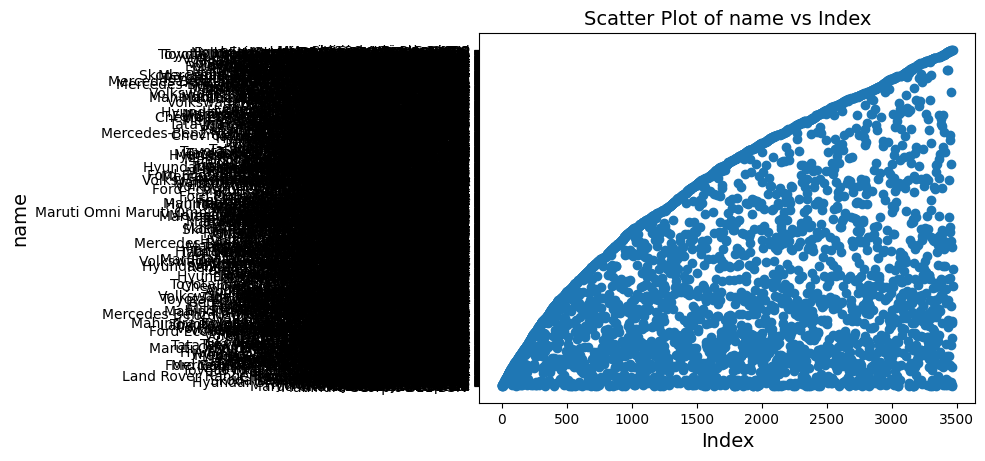

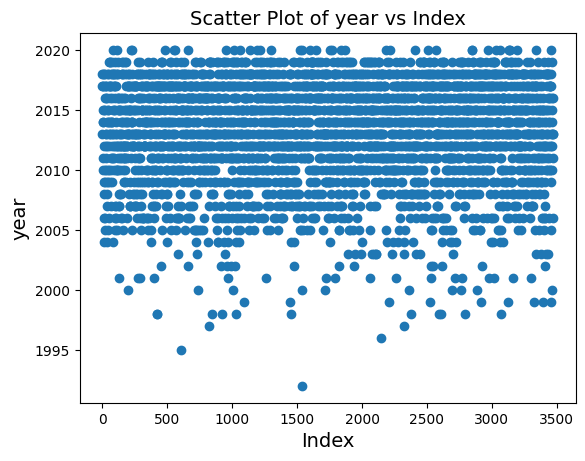

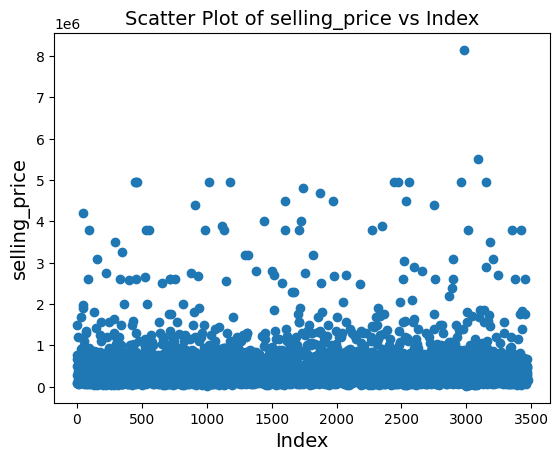

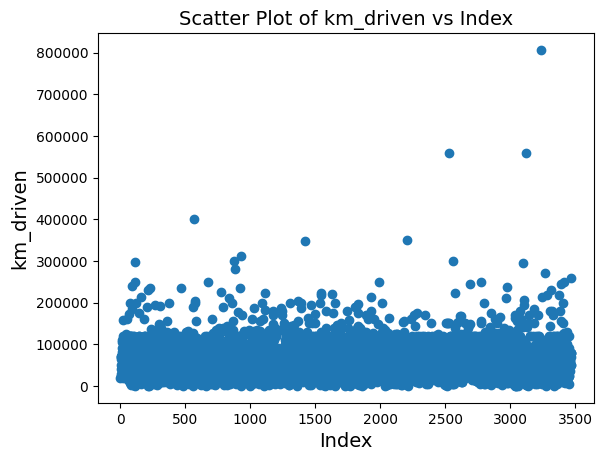

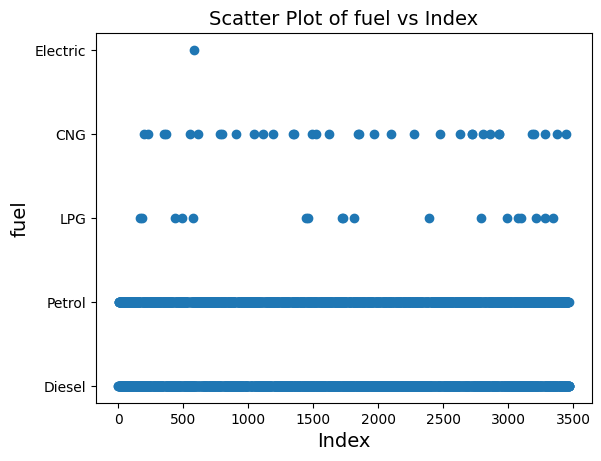

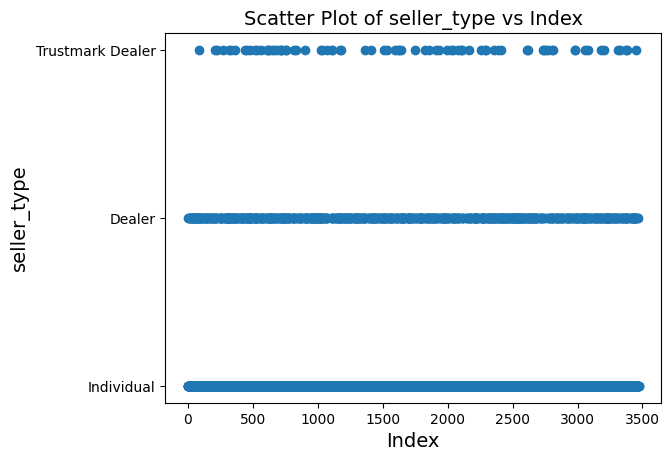

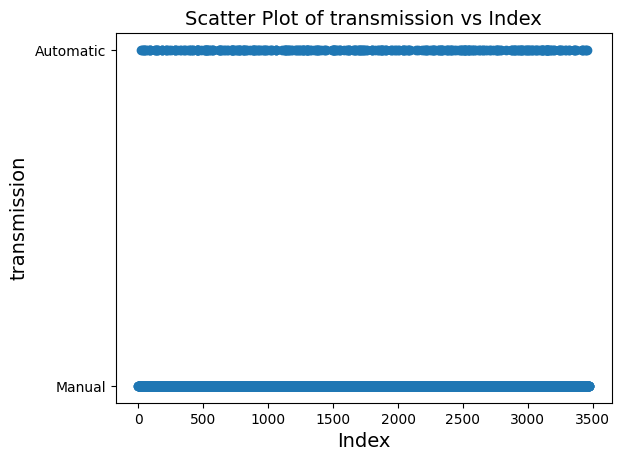

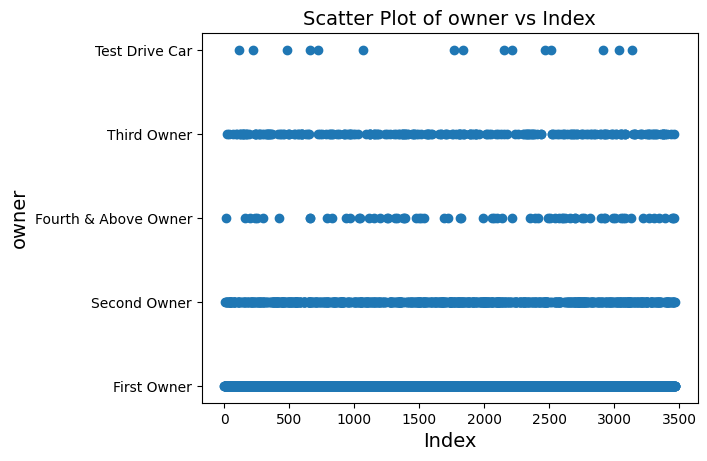

In [197]:
from matplotlib import pyplot as plt

def scatter_data(df: pd.DataFrame):
    """
    Create a scatter plot for the specified columns in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    x_col (str): The name of the column to be used for the x-axis.
    y_col (str): The name of the column to be used for the y-axis.
    """
    for y_col in df.columns:
        plt.scatter(range(len(df)), df[y_col])
        plt.xlabel('Index')
        plt.ylabel(y_col)
        plt.title(f'Scatter Plot of {y_col} vs Index')
        plt.show()

# Visualize the data
scatter_data(vehicle_cpy)

We can see some outliers for numerical data, maybe we could get ride of it.

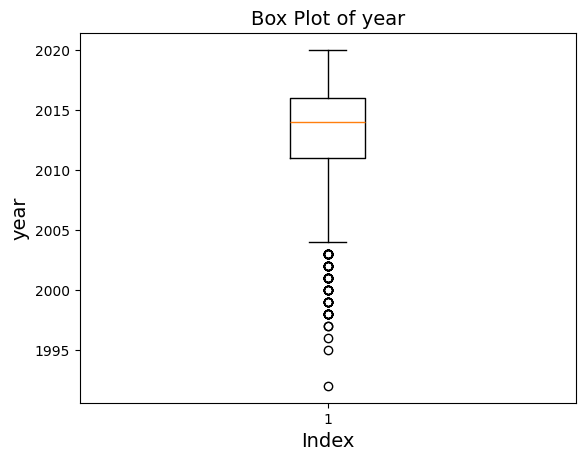

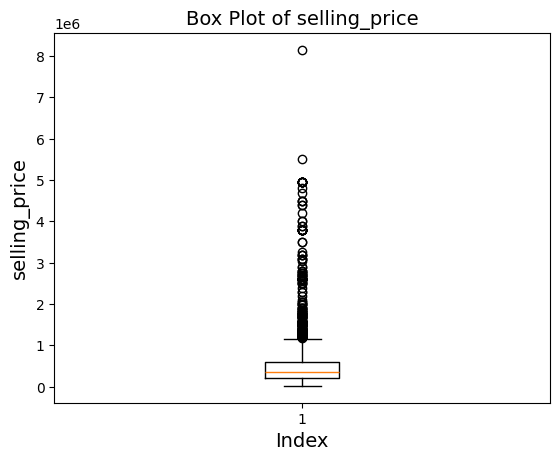

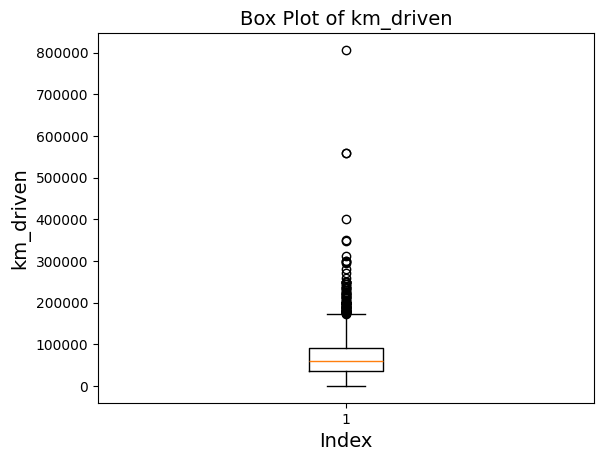

In [198]:
def boxplot_data(df: pd.DataFrame):
    """
    Create a box plot for the specified columns in the DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    x_col (str): The name of the column to be used for the x-axis.
    y_col (str): The name of the column to be used for the y-axis.
    """
    numeric_df = df.select_dtypes(include="number")
    for y_col in numeric_df.columns:
        plt.boxplot(df[y_col])
        plt.xlabel('Index')
        plt.ylabel(y_col)
        plt.title(f'Box Plot of {y_col}')
        plt.show()

# Visualize the data
boxplot_data(vehicle_cpy)

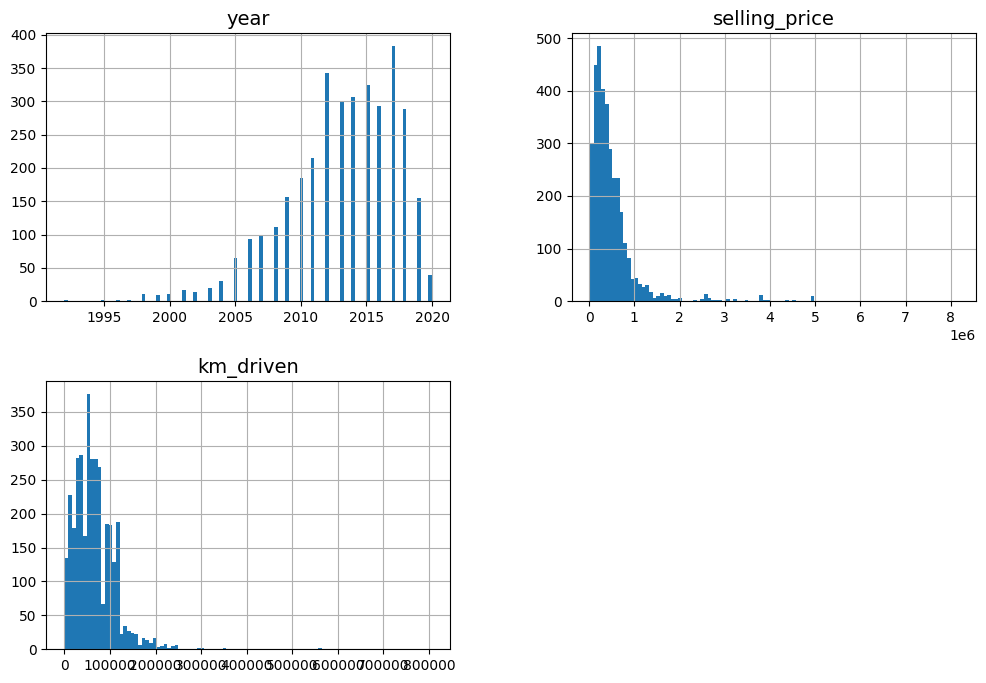

In [199]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

vehicle_cpy.hist(bins=100, figsize=(12, 8))

plt.show()

We can see that the distribution of the three numerical features are heavy tailed, so we will need to to some transformations later.

In [200]:
def plot_bar(df:pd.DataFrame) -> None:
    """
    Plot a bar chart of the value counts for a specified categorical column in a DataFrame.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    column_name (str): The name of the categorical column to plot.
    """
    for column in df.select_dtypes(include=['object']).columns:
        counts = df[column].value_counts()
        counts.plot(kind='bar', figsize=(10, 6))
        plt.title(f'Value Counts for {column}')
        plt.xlabel(column)
        plt.ylabel('Counts')
        plt.xticks(rotation=45)
        plt.show()

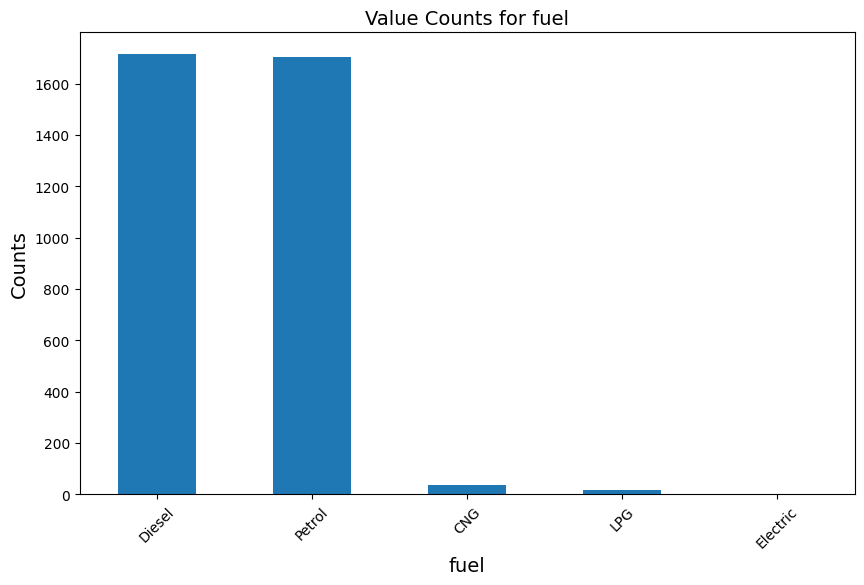

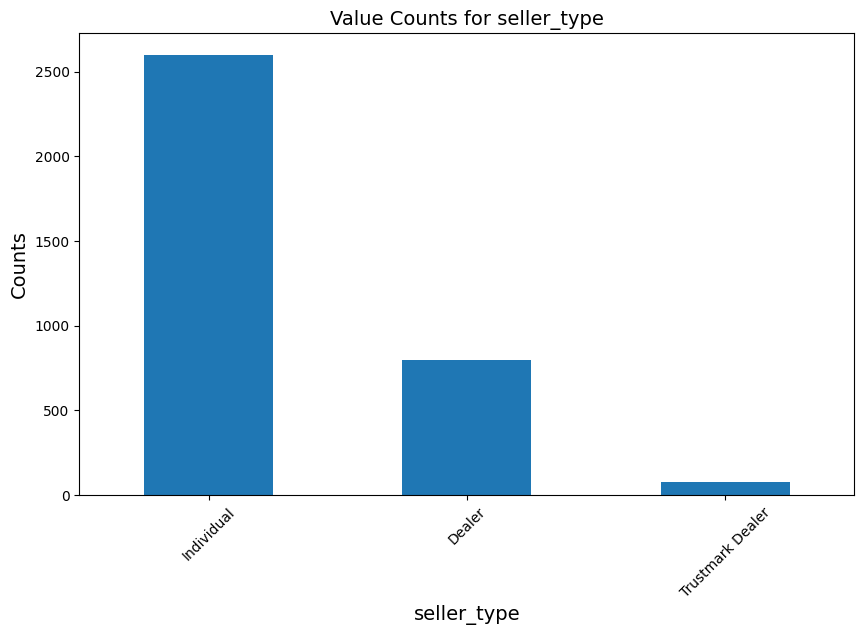

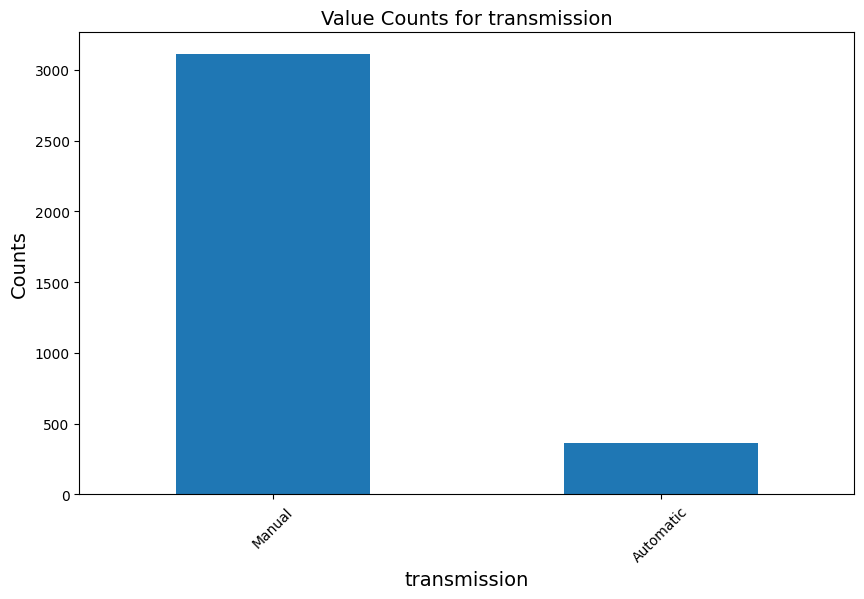

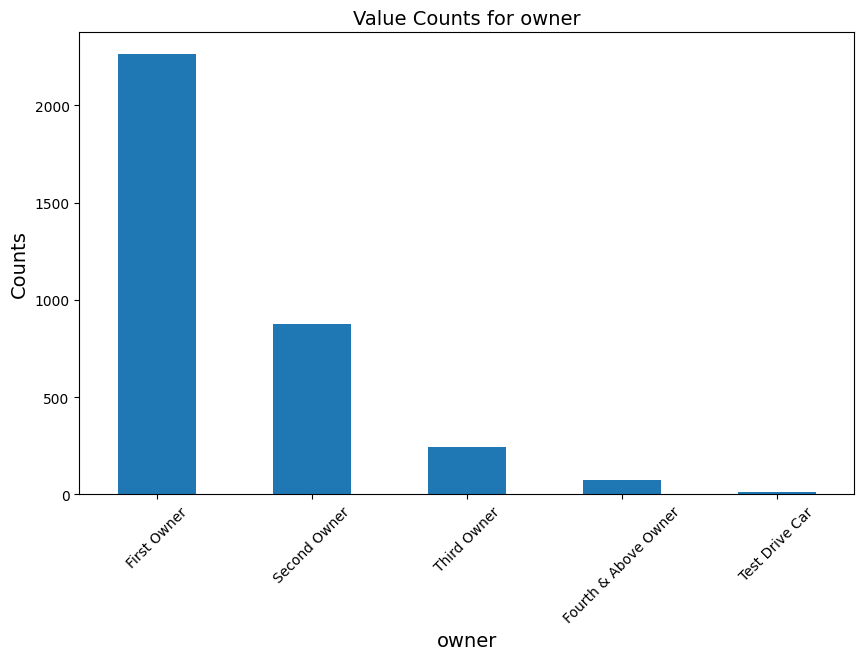

In [201]:
plot_bar(vehicle_cpy.drop(columns=['name']))  # Drop the target variable 'price' for plotting categorical features

We can see that we got 5 different fuels with very few samples for 3 of them so maybe we can group them as other. We also can see that their are 5 different categories for owner were we can apply the same logic. Basicly we get a lot of stratas.

We understand that the selling_price is our target output

In [202]:
corr_matrix = vehicle_cpy.corr(numeric_only=True)

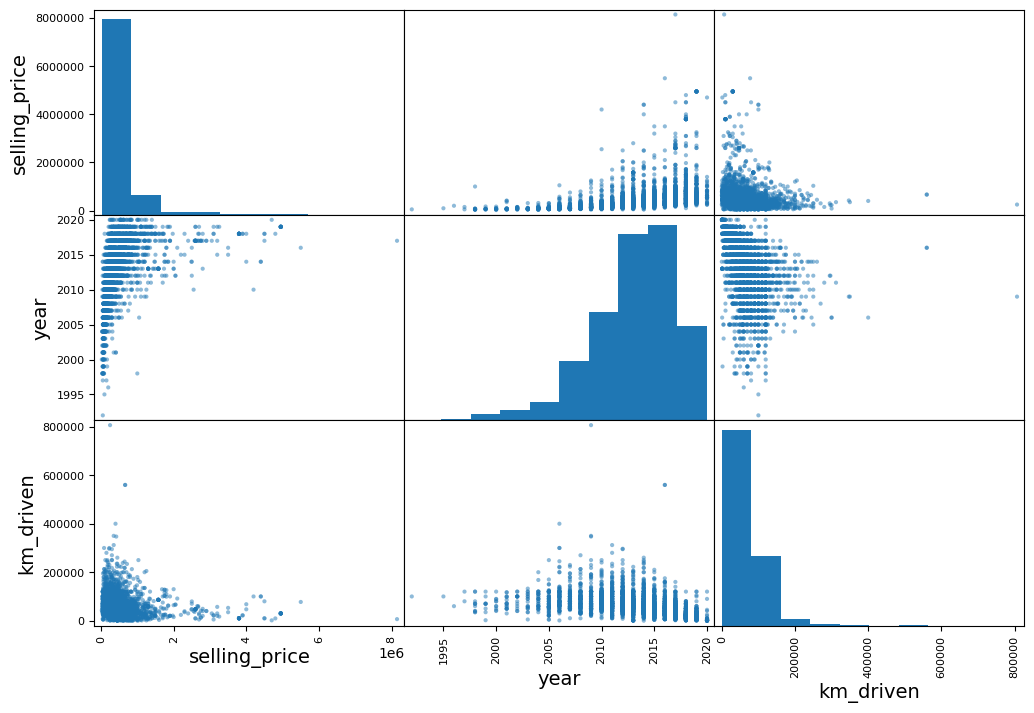

In [203]:
from pandas.plotting import scatter_matrix

attributes = ["selling_price", "year", "km_driven"]
scatter_matrix(vehicle_cpy[attributes], figsize=(12, 8))

plt.show()

## Prepare the Data

In [204]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import IsolationForest
import numpy as np

X_train = vehicle_train.copy()
X_train.drop("selling_price", axis=1, inplace=True)
y_train = vehicle_train["selling_price"]

X_test = vehicle_test.copy()
X_test.drop("selling_price", axis=1, inplace=True)  # selling_price retiré : c'est la cible (y)
y_test = vehicle_test["selling_price"]

class OutlierRemover(BaseEstimator, TransformerMixin):
    """
    Supprime les outliers détectés par IsolationForest, mais UNIQUEMENT
    pendant le fit (train). Au moment du transform seul (test/prod),
    aucune ligne n'est supprimée.
    """
    def __init__(self, contamination=0.05, random_state=42):
        self.contamination = contamination
        self.random_state = random_state

    def fit(self, X, y=None):
        self.iso_ = IsolationForest(
            contamination=self.contamination,
            random_state=self.random_state
        )
        self.iso_.fit(X.select_dtypes(include=[np.number]))
        return self

    def transform(self, X):
        # Au moment de l'inférence pure, on ne filtre rien
        return X

    def fit_transform(self, X, y=None):
        self.fit(X)
        mask = self.iso_.predict(X.select_dtypes(include=[np.number])) == 1
        self.mask_ = mask  # utile si tu veux aussi filtrer y en dehors du pipeline
        return X[mask]
    
remover = OutlierRemover(contamination=0.05, random_state=42)
X_train = remover.fit_transform(X_train)
y_train = y_train[remover.mask_]

In [205]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np



categorical_features = ['fuel', 'seller_type', 'transmission', 'owner','brand']
numeric_features = ['km_driven', 'car_age']  # selling_price retiré : c'est la cible (y)


def keep_only_brands(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()  # évite de muter le df d'origine
    df['name'] = df['name'].str.split(' ').str[0]  # garde uniquement le premier mot = la marque
    df = df.rename(columns={'name': 'brand'})       # renomme pour plus de clarté
    return df

def transform_to_categories(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()  # évite de muter le df d'origine

    # Age de la voiture plutôt que l'année brute
    df['car_age'] = 2026 - df['year']
    df = df.drop(columns=['year'])

    replace_fuel = {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'LPG': 2, 'Electric': 2}
    df['fuel'] = df['fuel'].map(replace_fuel)

    replace_seller_type = {'Individual': 0, 'Dealer': 1, 'Trustmark Dealer': 2}
    df['seller_type'] = df['seller_type'].map(replace_seller_type)

    replace_transmission = {'Manual': 0, 'Automatic': 1}
    df['transmission'] = df['transmission'].map(replace_transmission)

    replace_owner = {'First Hand': 0, 'Second Hand': 1, 'Third Hand': 2,
                      'Fourth & Above Hand': 2, 'Test Drive Car': 3}
    df['owner'] = df['owner'].map(replace_owner)

    return df


categorization_transformer = FunctionTransformer(transform_to_categories)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    #('sqrt', FunctionTransformer(np.sqrt, validate=True)),
    ('scale', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore')),
])

preprocessing = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

pipeline = Pipeline([
    ('extract_brands', FunctionTransformer(keep_only_brands)),
    ('categorize', categorization_transformer),
    ('preprocessing', preprocessing),
])

In [206]:
# Transform our data
pipeline.fit(X_train)
X_train_prepared = pipeline.transform(X_train)
X_test_prepared = pipeline.transform(X_test)

## Shortlisting models

I want to try linear regression and RandomForest regression

In [207]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn import set_config

set_config(display="diagram")


### Linear Regression

In [208]:
lin_reg = make_pipeline(pipeline, LinearRegression())
lin_reg.fit(X_train, y_train)

,steps,"[('pipeline', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('extract_brands', ...), ('categorize', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function kee...x72eaf45a8b80>
,inverse_func,None
,validate,False


In [209]:
lin_rmse = root_mean_squared_error(y_test, lin_reg.predict(X_test))
print(f"Linear Regression RMSE: {lin_rmse:.2f}")

Linear Regression RMSE: 381649.72


In [210]:
lin_rmses = -cross_val_score(lin_reg, X_train, y_train,
                                scoring="neg_root_mean_squared_error", cv=10)

In [211]:
pd.Series(lin_rmses).describe()

count        10.000000
mean     310531.477819
std       43983.945049
min      255131.611705
25%      280559.194663
50%      310322.539970
75%      322780.814299
max      405936.594085
dtype: float64

### Random Forest

In [212]:
rdf_reg = make_pipeline(pipeline, RandomForestRegressor(random_state=42))
rdf_reg.fit(X_train, y_train)

,steps,"[('pipeline', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('extract_brands', ...), ('categorize', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function kee...x72eaf45a8b80>
,inverse_func,None
,validate,False


In [213]:
rdf_rmse = root_mean_squared_error(y_test, rdf_reg.predict(X_test))
print(f"Random Forest RMSE: {rdf_rmse:.2f}")

Random Forest RMSE: 274711.55


In [214]:
forest_rmses = -cross_val_score(rdf_reg, X_train, y_train,
                                scoring="neg_root_mean_squared_error", cv=10)

In [215]:
pd.Series(forest_rmses).describe()

count        10.000000
mean     260015.335676
std       59495.401753
min      169567.105783
25%      223243.274262
50%      255398.487449
75%      303660.495487
max      357740.499190
dtype: float64

### Fine-tuning

In [216]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint,uniform

param_distributions = {
    'randomforestregressor__n_estimators': randint(100, 500),
    'randomforestregressor__max_depth': randint(5, 30),
    'randomforestregressor__min_samples_split': randint(2, 20),
    'randomforestregressor__min_samples_leaf': randint(1, 10),
    'randomforestregressor__max_features': uniform(0.3, 0.7),  # entre 0.3 et 1.0
}


rnd_search = RandomizedSearchCV(
    rdf_reg, param_distributions=param_distributions, n_iter=100, cv=10,
    scoring='neg_root_mean_squared_error', random_state=42,n_jobs=-1)

rnd_search.fit(X_train, y_train)

/home/sebastian/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/sebastian/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/sebastian/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/late

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'randomforestregressor__max_depth': <scipy.stats....x72eafb664290>, 'randomforestregressor__max_features': <scipy.stats....x72eaf73074d0>, 'randomforestregressor__min_samples_leaf': <scipy.stats....x72eafae2d670>, 'randomforestregressor__min_samples_split': <scipy.stats....x72eafae2c950>, ...}"
,n_iter,100
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


## Evaluate the best model

In [217]:
final_model = rnd_search.best_estimator_  # includes preprocessing
feature_importances = final_model['randomforestregressor'].feature_importances_
feature_importances.round(2)

array([0.11, 0.17, 0.05, 0.07, 0.  , 0.02, 0.02, 0.  , 0.14, 0.14, 0.  ,
       0.  , 0.02, 0.07, 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.01, 0.  ,
       0.01, 0.  , 0.  , 0.02, 0.  , 0.01, 0.01, 0.08, 0.  , 0.  , 0.  ,
       0.  , 0.01, 0.02, 0.01, 0.01])

In [218]:
column_transformer = final_model.named_steps['preprocessing'].named_steps['preprocessing']
feature_names = column_transformer.get_feature_names_out()

feature_importances = final_model.named_steps['model'].feature_importances_

sorted(zip(feature_importances, feature_names), reverse=True)

KeyError: 'preprocessing'

In [219]:
final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

302195.5087671243


In [220]:

errors_pct = np.abs((y_test - final_predictions) / y_test) * 100

print(f"Erreur moyenne : {errors_pct.mean():.2f}%")
print(f"Erreur médiane : {errors_pct.median():.2f}%")
print(f"Écart-type : {errors_pct.std():.2f}%")

Erreur moyenne : 31.64%
Erreur médiane : 20.69%
Écart-type : 40.74%
